# Section: Hyperbola Fitting to Estimate Velocity

In the figure given in the paper we essentially overlap a bunch of point reflectors to simulate a contact and finite-impedance reflectors (the tapering), depite the homogenous velocity medium. This gives the illusion of a more realistic hyperbola. This notebook will cover our hyperbola fitting workflow, thresholding-->c3-->smooth path algorithm--> hyperbolic template

In [105]:
import math
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../..')

from SimulatingGPR import gprsim
import gpr_c3_clustering

In [106]:

nx, nz = 80, 100
dx = dz = 0.5 # 1 m grid

# Permittivity model (background)
eps = np.ones((nx, nz)) * 4  # ε_r = 9 (sand)


# Add buried object
eps[9:11, 38:40] = 7  # lower permittivity block
eps[9:11, 58:60] = 7  # lower permittivity block
  

'''
Generate the Standard
'''
dt = 1e-9
t_max = 300e-9
f0 = 2.5e7
np.random.seed(1001)
radargram, x, t = gprsim.gpr_finite_difference_abc(
    eps.T,
    dx=dx,
    dz=dz,
    dt=dt,
    t_max=t_max,
    f0=f0,
    trace_spacing=1,
    SNR=np.inf
)

Points per wavelength: 9.1
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] 299


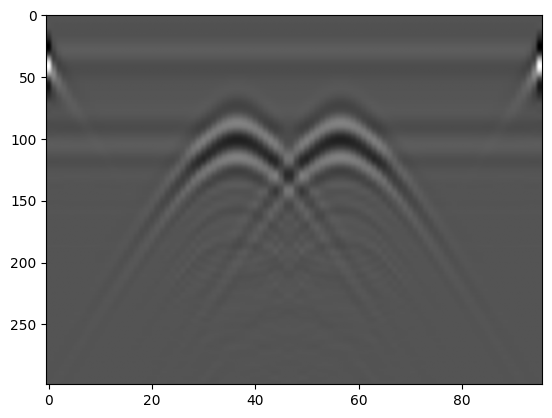

In [110]:
data_demeaned = radargram[:, 2:-2] - np.mean(radargram[:, 2:-2], axis=1, keepdims=True)*0.998
plt.imshow(data_demeaned, aspect='auto', cmap='gray')
# abs_mask = np.abs(data_demeaned)
# mask = np.zeros_like(data_demeaned)
# mask[np.where(abs_mask>np.percentile(abs_mask, 90))] = 1
# mask[np.where(abs_mask<=np.percentile(abs_mask, 90))] = 0
# plt.imshow(mask, aspect='auto')

Found 8 clusters
  Cluster 0: 540 points, columns 3-92
  Cluster 1: 77 points, columns 8-24
  Cluster 2: 558 points, columns 22-71
  Cluster 3: 230 points, columns 23-45
  Cluster 4: 230 points, columns 48-70
  Cluster 5: 85 points, columns 69-87
  Cluster 6: 158 points, columns 22-36
  Cluster 7: 400 points, columns 37-71
[23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45] [161 156 150 145 140 135 132 128 125 122 120 118 116 115 115 116 118 120
 122 125 129 131 134]


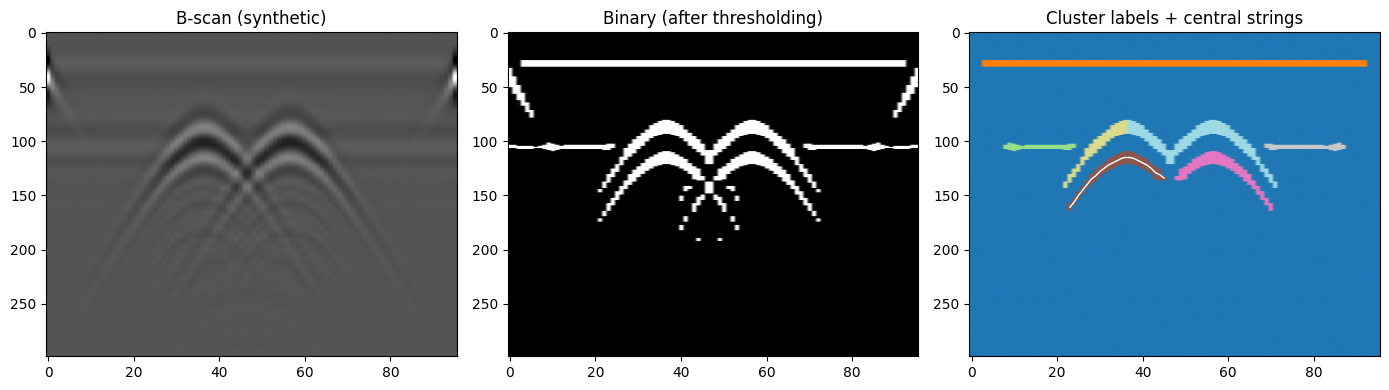

In [111]:
"""
Column-Connection Clustering (C3) Algorithm for GPR B-scan data.
Based on: Dou et al. (2017) "Real-Time Hyperbola Recognition and Fitting in GPR Data"
IEEE Transactions on Geoscience and Remote Sensing, 55(1), pp. 51-62.

Assumes the B-scan has already been pre-processed (e.g. mean subtraction, filtering).
"""

import numpy as np
from dataclasses import dataclass, field
from typing import Optional


@dataclass
class Cluster:
    """A cluster produced by the C3 algorithm."""
    id: int
    # Maps column index -> list of row indices belonging to this cluster
    columns: dict = field(default_factory=dict)

    @property
    def all_points(self) -> np.ndarray:
        """Return all (row, col) points in the cluster as an (N, 2) array."""
        pts = [(r, c) for c, rows in self.columns.items() for r in rows]
        return np.array(pts, dtype=int) if pts else np.empty((0, 2), dtype=int)

    @property
    def central_string(self) -> np.ndarray:
        """
        Return the central string: the midpoint row for each column,
        as an (M, 2) array of (row, col) sorted by column.
        """
        cols = sorted(self.columns.keys())
        return np.array(
            [(int(np.mean(self.columns[c])), c) for c in cols], dtype=int
        )

    @property
    def width(self) -> int:
        return len(self.columns)

    @property
    def size(self) -> int:
        return sum(len(v) for v in self.columns.values())


def threshold_bscan(bscan: np.ndarray, rho_b: float = 0.1) -> np.ndarray:
    """
    Adaptive thresholding (Section II-A of the paper).

    Computes a threshold from edge pixel intensities:
        threshold = mean{ Ie | Ie > rho_b * max(Ie) }

    Args:
        bscan:  2-D float array, already pre-processed.
        rho_b:  Fraction in (0, 1). Paper uses 0.1 by default.

    Returns:
        Binary 2-D uint8 array (1 = region of interest, 0 = background).
    """
    # Simple gradient-magnitude edge map
    gy = np.abs(np.diff(bscan, axis=0, prepend=bscan[:1]))
    gx = np.abs(np.diff(bscan, axis=1, prepend=bscan[:, :1]))
    edge_mag = np.hypot(gx, gy)

    edge_vals = edge_mag[edge_mag > 0]
    if edge_vals.size == 0:
        return np.zeros_like(bscan, dtype=np.uint8)

    max_ie = edge_vals.max()
    selected = edge_vals[edge_vals > rho_b * max_ie]
    thresh = selected.mean() if selected.size > 0 else max_ie

    binary = (bscan >= thresh).astype(np.uint8)
    return binary


def _get_column_segments(col: np.ndarray, s: int) -> list[list[int]]:
    """
    Extract column segments: runs of consecutive non-zero pixels of length >= s.

    Args:
        col: 1-D binary array for one column.
        s:   Minimum run length.

    Returns:
        List of segments, each segment is a list of row indices.
    """
    segments = []
    n = len(col)
    i = 0
    while i < n:
        if col[i]:
            j = i
            while j < n and col[j]:
                j += 1
            run_rows = list(range(i, j))
            if len(run_rows) >= s:
                segments.append(run_rows)
            i = j
        else:
            i += 1
    return segments


def _connecting_elements(seg_a: list[int], seg_b: list[int]) -> int:
    """Count elements (rows) shared between two column segments."""
    return len(set(seg_a) & set(seg_b))


def c3_clustering(
    bscan: np.ndarray,
    s: int = 3,
    threshold: Optional[float] = None,
    rho_b: float = 0.1,
    min_cluster_width: int = 3,
    apply_derivative_split: bool = True,
) -> tuple[list[Cluster], np.ndarray]:
    """
    Column-Connection Clustering (C3) algorithm (Section II-B).

    Args:
        bscan:                 2-D float array (rows = time samples, cols = traces).
                               Should already be pre-processed.
        s:                     Minimum consecutive-pixel run length for a column
                               segment. Paper uses s=3. Acts as a noise gate.
        threshold:             If provided, use this fixed threshold value to binarise
                               the bscan instead of the adaptive method.
        rho_b:                 Parameter for the adaptive thresholding (ignored when
                               `threshold` is given). Paper default: 0.1.
        min_cluster_width:     Discard clusters that span fewer columns than this.
        apply_derivative_split: If True, apply the second-pass derivative-based split
                               for fused double-hyperbola clusters (Section II-B).

    Returns:
        clusters:   List of Cluster objects.
        binary:     The binary image produced by thresholding.
    """
    if bscan.ndim != 2:
        raise ValueError("bscan must be a 2-D array.")

    # ------------------------------------------------------------------ #
    # 1. Binarise
    # ------------------------------------------------------------------ #
    if threshold is not None:
        binary = (bscan >= threshold).astype(np.uint8)
    else:
        binary = threshold_bscan(bscan, rho_b=rho_b)

    n_rows, n_cols = binary.shape

    # ------------------------------------------------------------------ #
    # 2. C3 scan (left → right)
    # ------------------------------------------------------------------ #
    # active_clusters is a list of Cluster objects currently being extended.
    active_clusters: list[Cluster] = []
    cluster_id = 0

    for col_idx in range(n_cols):
        col_segs = _get_column_segments(binary[:, col_idx], s)

        if col_idx == 0:
            # Seed one cluster per column segment in the first column
            for seg in col_segs:
                c = Cluster(id=cluster_id)
                c.columns[col_idx] = seg
                active_clusters.append(c)
                cluster_id += 1
            continue

        # For each new column segment, find which active clusters connect to it
        new_active: list[Cluster] = []
        seg_handled = [False] * len(col_segs)

        for clust in active_clusters:
            # Does this cluster's last column connect to any new segment?
            last_col = max(clust.columns.keys())
            if last_col != col_idx - 1:
                # Cluster already stopped; keep it dormant (we'll flush later)
                new_active.append(clust)
                continue

            prev_seg = clust.columns[last_col]
            matched_segs = [
                (j, seg) for j, seg in enumerate(col_segs)
                if _connecting_elements(prev_seg, seg) >= 1
            ]

            if not matched_segs:
                # No connection → cluster stops here
                new_active.append(clust)
            elif len(matched_segs) == 1:
                # Exactly one match → extend the cluster
                j, seg = matched_segs[0]
                clust.columns[col_idx] = seg
                seg_handled[j] = True
                new_active.append(clust)
            else:
                # Multiple matches → split into child clusters
                for j, seg in matched_segs:
                    child = Cluster(id=cluster_id)
                    cluster_id += 1
                    # Copy parent history
                    for cc, rows in clust.columns.items():
                        child.columns[cc] = list(rows)
                    child.columns[col_idx] = seg
                    seg_handled[j] = True
                    new_active.append(child)

        # Any unmatched new segments start fresh clusters
        for j, seg in enumerate(col_segs):
            if not seg_handled[j]:
                c = Cluster(id=cluster_id)
                c.columns[col_idx] = seg
                new_active.append(c)
                cluster_id += 1

        active_clusters = new_active

    all_clusters = active_clusters  # everything is now finalised

    # ------------------------------------------------------------------ #
    # 3. Filter by minimum width
    # ------------------------------------------------------------------ #
    all_clusters = [c for c in all_clusters if c.width >= min_cluster_width]

    # ------------------------------------------------------------------ #
    # 4. Optional: derivative-based split for fused double-hyperbola shapes
    #    (Section II-B, Figure 7)
    #    Detects a local minimum in the central string (dy/dx = 0, d²y/dx² > 0)
    #    and breaks the cluster there.
    # ------------------------------------------------------------------ #
    if apply_derivative_split:
        extra: list[Cluster] = []
        for clust in all_clusters:
            cs = clust.central_string  # shape (W, 2) — (row, col)
            if len(cs) < 5:
                continue
            rows = cs[:, 0].astype(float)
            # First finite difference as proxy for dy/dx
            dy = np.diff(rows)
            # Look for a sign change from negative→positive (valley = local min in row)
            split_col_idx = None
            for k in range(1, len(dy)):
                if dy[k - 1] < 0 and dy[k] >= 0:
                    # Second derivative check (positive = valley)
                    if k + 1 < len(dy) and (dy[k] - dy[k - 1]) > 0:
                        split_col_idx = k  # index into cs
                        break

            if split_col_idx is None:
                continue

            split_col = cs[split_col_idx, 1]  # actual column number
            cols_sorted = sorted(clust.columns.keys())

            left_cols = [c for c in cols_sorted if c <= split_col]
            right_cols = [c for c in cols_sorted if c > split_col]

            if len(left_cols) < min_cluster_width or len(right_cols) < min_cluster_width:
                continue  # not worth splitting

            left_c = Cluster(id=cluster_id)
            cluster_id += 1
            for c in left_cols:
                left_c.columns[c] = clust.columns[c]

            right_c = Cluster(id=cluster_id)
            cluster_id += 1
            for c in right_cols:
                right_c.columns[c] = clust.columns[c]

            extra.extend([left_c, right_c])

        all_clusters.extend(extra)

    # ------------------------------------------------------------------ #
    # 5. Re-assign contiguous IDs and return
    # ------------------------------------------------------------------ #
    for new_id, clust in enumerate(all_clusters):
        clust.id = new_id

    return all_clusters, binary


# --------------------------------------------------------------------------- #
# Convenience helpers
# --------------------------------------------------------------------------- #

def cluster_label_image(clusters: list[Cluster], shape: tuple[int, int]) -> np.ndarray:
    """
    Return an integer label image of shape `shape`.
    Background = 0; cluster i gets label i+1.
    """
    label_img = np.zeros(shape, dtype=np.int32)
    for clust in clusters:
        for col, rows in clust.columns.items():
            for r in rows:
                if 0 <= r < shape[0] and 0 <= col < shape[1]:
                    label_img[r, col] = clust.id + 1
    return label_img


def mask_cluster(bscan: np.ndarray, cluster: Cluster) -> np.ndarray:
    """Return a boolean mask (same shape as bscan) for a single cluster."""
    mask = np.zeros(bscan.shape, dtype=bool)
    for col, rows in cluster.columns.items():
        for r in rows:
            if 0 <= r < bscan.shape[0] and 0 <= col < bscan.shape[1]:
                mask[r, col] = True
    return mask


# --------------------------------------------------------------------------- #
# Example usage
# --------------------------------------------------------------------------- #
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # # --- Synthetic B-scan with two overlapping hyperbola-shaped blobs ---
    # rows, cols = 200, 300
    bscan = data_demeaned

    # def add_hyperbola(img, x0, y0, a=20, b=40, amp=1.0, width=3):
    #     for x in range(img.shape[1]):
    #         dx = x - x0
    #         val = y0 + a * np.sqrt(1 + (dx / b) ** 2)
    #         y_int = int(round(val))
    #         for dy in range(-width, width + 1):
    #             yy = y_int + dy
    #             if 0 <= yy < img.shape[0]:
    #                 img[yy, x] += amp * max(0, 1 - abs(dy) / width)

    # add_hyperbola(bscan, x0=80,  y0=30, a=15, b=35, amp=1.0)
    # add_hyperbola(bscan, x0=200, y0=50, a=20, b=50, amp=0.9)

    clusters, binary = c3_clustering(
        bscan = bscan,
        s=3,
        rho_b=0.01,
        min_cluster_width=10,
        apply_derivative_split=True,
    )

    print(f"Found {len(clusters)} clusters")
    for c in clusters:
        pts = c.all_points
        print(f"  Cluster {c.id}: {pts.shape[0]} points, "
              f"columns {min(c.columns)}-{max(c.columns)}")

    label_img = cluster_label_image(clusters, bscan.shape)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(bscan, cmap="gray", aspect="auto")
    axes[0].set_title("B-scan (synthetic)")
    axes[1].imshow(binary, cmap="gray", aspect="auto")
    axes[1].set_title("Binary (after thresholding)")
    axes[2].imshow(label_img, cmap="tab20", aspect="auto")
    # Overlay central strings
    for c in [clusters[3]]:
        cs = c.central_string
        if len(cs) > 1:
            print(cs[:, 1], cs[:, 0])
            axes[2].plot(cs[:, 1], cs[:, 0], "w-", linewidth=1)
    axes[2].set_title("Cluster labels + central strings")
    plt.tight_layout()


[23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45] [161 156 150 145 140 135 132 128 125 122 120 118 116 115 115 116 118 120
 122 125 129 131 134]
1.5441430784800982


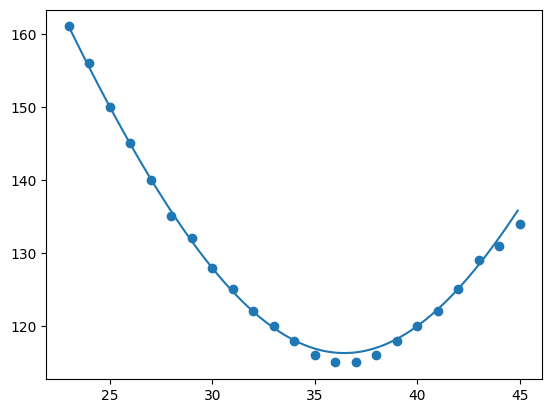

In [112]:
for c in [clusters[3]]:
        cs = c.central_string
        if len(cs) > 1:
            print(cs[:, 1], cs[:, 0])
            plt.scatter(cs[:, 1], cs[:, 0])

x = clusters[3].central_string[:, 1]
t = clusters[3].central_string[:, 0]
v, x0, t0 = fit_hyperbola(data_demeaned, 1, 'robust_fit', 1, 1, x, t/2)
print((0.3/v)**2)
def hyperbola(x, v, x0, t0):
    y = np.sqrt(t0**2 + (np.abs(x-x0)/(v))**2)
    return y*2

x_guessed = np.arange(np.min(x), np.max(x), 0.1)
t_guessed = hyperbola(x_guessed, v, x0, t0)
plt.plot(x_guessed, t_guessed)

In [113]:
def fit_hyperbola(data, num_hyperbolas, method, dx, dt, x, t):

    if method=='robust_fit':
        # we want the physical coords of x, t
        x*=dx # dx in meters per pixel
        t*=dt # dt in **ns** per pixel
        
        # Our linearized form of the hyperbola equation
        A = np.column_stack([x**2, -2*x, 1.0*np.ones_like(x)])
        b = t**2
        
        # solve with pseudoinverse -- do this twice to reduce outliers
        consts = np.linalg.pinv(A) @ b
        r = A@consts - b  
        sigma = 1.5 * np.median(np.abs(r - np.median(r))) # scale mad
        
        mask = np.abs(r) <= 0.5 * sigma
        consts2 = np.linalg.pinv(A[mask]) @ b[mask]
        alpha, beta, gamma = consts2
        
        if alpha == 'bad':
            print(Fore.RED + "Caught invalud value in sqrt: can not calculate hyperbola parameters from pinv. Switching to np.polyfit to avoid distruption. If np.polyfit quits, the input data may be too noisy")
            return fit_hyperbola(c, num_hyperbolas, 'fit_from_max', dx, dt, x, t)
        else:
            v = np.sqrt(1/alpha)
            x0 = beta/alpha
            t0 = np.sqrt(gamma-(x0**2/v**2))
        # print(f"v = {v:.1f} m/s, depth z = {z:.2f} m, apex x0 = {x0:.3f} m, t0 = {t0} s, risiduals={r}")
        return v, x0, t0

    return None